# Розрахунок площ фермерського господарства
### Використання алгоритму Гаусса (формула площі шнурівки)

**Мета роботи:** Автоматизувати процес розрахунку площі земельних ділянок складної форми за допомогою координат GPS та візуалізувати план ферми.

> **Математична основа:** Для обчислення площі багатокутника без самоперетинів використовується **формула Гаусса**. Якщо вершини задані координатами $(x_i, y_i)$, то площа $A$ визначається як:
> $$A = \frac{1}{2} \left| \sum_{i=1}^{n-1} (x_i y_{i+1} - x_{i+1} y_i) + (x_n y_1 - x_1 y_n) \right|$$

In [1]:
field = [(0,0), (4,0), (5,3), (2,5), (0,3)] #координати поля (багатокутник)
barn = [(1,1), (2,1), (2,2), (1,2)] #координати сараю

In [2]:
def polygon_area(points):
    """
    Обчислює площу багатокутника за формулою Гауса
    :param points: список точок (х,у)
    :return:
    """
    n = len(points) # кількість вершин
    area = 0
    for i in range(n):
        x1, y1 = points[i] #поточна точка
        x2, y2 = points[(i + 1) % n] #наступна точка (з замиканням на першу)
        area += x1 * y2 - x2 * y1 #формула Гауса
    return abs(area) / 2

In [3]:
field_area = polygon_area(field)
barn_area = polygon_area(barn)
free_area = field_area - barn_area  #вільна площа (без сараю)
print("Площа поля: ", field_area)
print("Площа сараю: ", barn_area)
print("Вільна площа: ", free_area)

Площа поля:  18.5
Площа сараю:  1.0
Вільна площа:  17.5


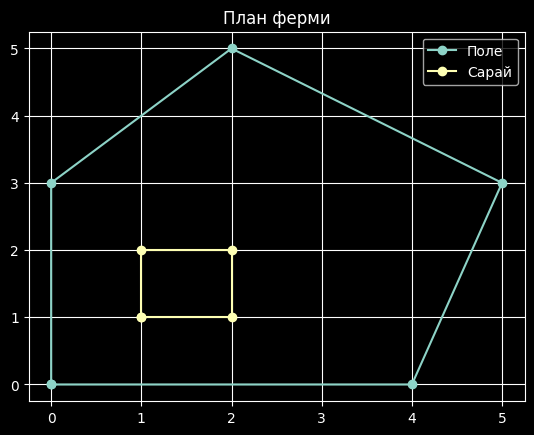

In [4]:
import matplotlib.pyplot as plt
def plot_polygon(points, label):
    """
    малює багатокутник
    """
    x = [p[0] for p in points] + [points[0][0]]
    y = [p[1] for p in points] + [points[0][1]]
    plt.plot(x, y, marker='o', label=label) #малювання ліній

plt.figure()
plot_polygon(field, "Поле")
plot_polygon(barn, "Сарай")
plt.legend()
plt.grid()
plt.title("План ферми")
plt.show()